In [4]:
import re
import numpy as np
import pandas as pd
from sys import argv
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.colors import LogNorm, LinearSegmentedColormap

#Data preparation
def parse_results(filename):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            parts = line.split()
            # Estraiamo threshold (es. 1e-05), Q2 e MCC
            th = float(parts[1]) # E-value threshold
            q2 = float(parts[3]) # Q2
            mcc = float(parts[5])#MCC
            data.append([th, q2, mcc])
    return pd.DataFrame(data, columns=['Threshold', 'Q2', 'MCC'])


df1 = parse_results('kunitz_set_1.results')
df2 = parse_results('kunitz_set_2.results')

In [5]:
#MCCvsEvaluePLOT
import matplotlib.pyplot as plt

def plot_mcc_vs_evalue(df1, df2):

    plt.style.use('seaborn-v0_8-whitegrid') 
    plt.figure(figsize=(12, 7))

    # Plot kunitz_set 1
    plt.plot(df1['Threshold'], df1['MCC'], 
             color='#008080',          
             marker='o',               
             markersize=8,             
             linewidth=1,              
             label='Kunitzset1')

    # Plot kunitz_set 2
    plt.plot(df2['Threshold'], df2['MCC'], 
             color='#8b4513',          
             marker='v',               
             markersize=8, 
             linestyle='-',           
             linewidth=1, 
             alpha=0.8,                
             label='Kunitzset2')

    plt.xscale('log')
    #plt.gca().invert_xaxis()

    plt.xlabel('E-value Threshold (log scale)', 
               fontsize=12, fontweight='bold', labelpad=10)

    plt.ylabel('MCC (Matthews Correlation Coefficient)', 
               fontsize=12, fontweight='bold', labelpad=10)

    plt.grid(True, which="both", ls=":", alpha=0.6, color='gray')

    plt.legend(title='Datasets', 
               title_fontsize='11', 
               frameon=True, 
               shadow=True, 
               loc='lower left')

    plt.tight_layout() 
    plt.savefig('MCC_Evalue.png', dpi=300)
    plt.show()

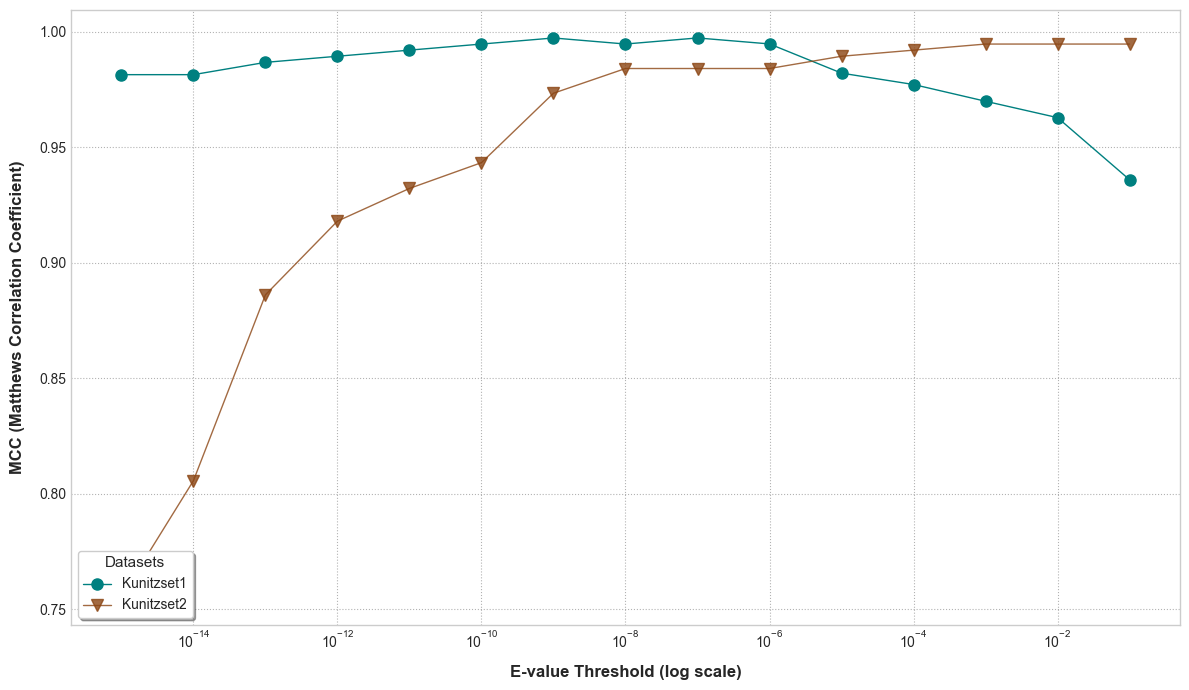

In [6]:
plot_mcc_vs_evalue(df1, df2)